<div align="center">
  <hr>
  <h1>Análise de Dados do Mercado Editorial com SQL.</h1>
  
  <hr>
</div>

## Sumário
1.  [**Objetivos**](#Objetivos)
2.  [**Análise Inicial e Qualidade dos Dados**](#Anállise-inicial)
3.  [**Análise Estratégica via SQL**](#Análise-Estratégica-via-SQL)
    *   [3.1. Quantidade de livros após 1 de janeiro de 2000](#Quantidade-de-livros-após-1-de-janeiro-de-2000)
    *   [3.2. Avaliações & Classificação média / livro](#Avaliações-&-Classificação-média-/-livro)
    *   [3.3. Editora com mais livros longos(+50paginas)](#Editora-com-mais-livros-longos(+50paginas))
    *   [3.4. Autor(s) com melhor avaliação](#Autor(s)-com-melhor-avaliação)
    *   [3.5. Engajamento Textual dos Usuários Mais Ativos](#Engajamento-Textual-dos-Usuários-Mais-Ativos)
4.  [**Conclusão**](#Conclusão)
    *   [4.1. Resumo dos Principais Insights](#Resumo-dos-Principais-Insights)
    *   [4.2. Limitações da Análise](#Limitações-da-Análise)
    *   [4.3. Recomendações Estratégicas para o Novo Aplicativo](#Recomendações-Estratégicas-para-o-Novo-Aplicativo)

## Objetivos

O objetivo principal deste projeto é **analisar o banco de dados de um serviço concorrente** para extrair insights estratégicos que fundamentem a proposição de valor e as funcionalidades de um novo aplicativo para leitores.

Especificamente, a análise visa:

1.  **Quantificar o volume de publicações** lançadas após 1 de janeiro de 2000, a fim de avaliar a relevância e atualidade do acervo disponível.
2.  **Mapear o desempenho de cada livro**, calculando o número total de avaliações e a classificação média para identificar os títulos com maior engajamento e aceitação pelo público.
3.  **Identificar a editora com o maior volume de publicações** com mais de 50 páginas, visando reconhecer os parceiros de mercado mais prolíficos em obras de conteúdo substancial.
4.  **Determinar o autor com a maior média de classificação**, considerando apenas livros com um volume mínimo de 50 classificações, para destacar os criadores de conteúdo de maior prestígio e impacto.
5.  **Analisar o comportamento dos usuários mais ativos**, calculando o número médio de resenhas textuais entre aqueles que avaliaram mais de 50 livros, para compreender os padrões de engajamento do público-alvo.

In [1]:
import pandas as pd
from IPython.display import display, Markdown
from sqlalchemy import create_engine

In [2]:
db_config = {
 'user': 'practicum_student', # username
 'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7', # password
 'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
 'port': 5432, # connection port
 'db': 'data-analyst-final-project-db' # the name of the database
 }
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(db_config['user'],db_config['pwd'],db_config['host'],db_config['port'],db_config['db'])
engine = create_engine(connection_string, connect_args={'sslmode':'require'})

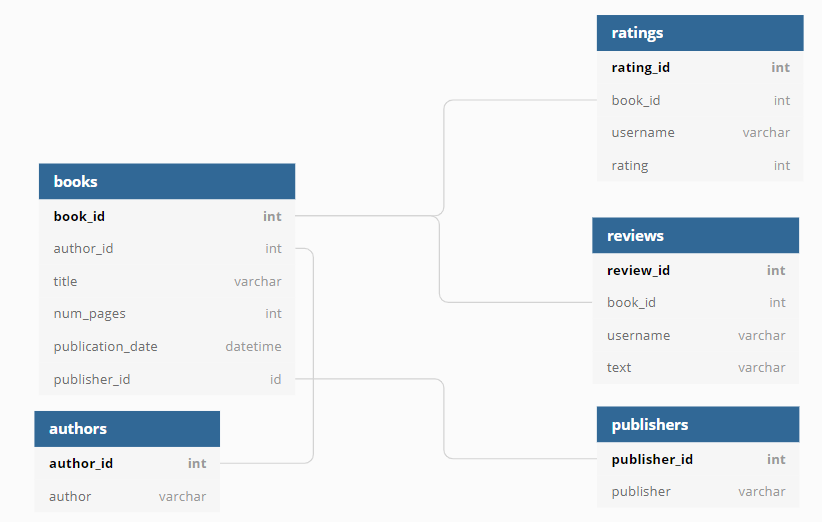

In [3]:


def exibir_consulta(query_sql: str, titulo: str):
    """
    Executa uma consulta SQL e exibe o resultado em um DataFrame do pandas.
    """
    display(Markdown(f'{titulo}'))
    # Executa a query e armazena o resultado em um DataFrame
    df = pd.read_sql(query_sql, con=engine)
    # Exibe o DataFrame
    display(df)
        

In [4]:
def mostrar(x):
    exibir_consulta(titulo=f"### Amostra da Tabela '{x}'",
                query_sql = f"""
SELECT
    *
FROM
    {x}
LIMIT 5;
""")
    exibir_consulta(titulo="Contagem",
                query_sql = f"""
SELECT
    count(*)
FROM
    {x};
""")
    
    
tabelas = ["books" ,"authors" ,"publishers" ,"ratings" ,"reviews"]
for tabela in tabelas:
    mostrar(tabela)

### Amostra da Tabela 'books'

,book_id,author_id,title,num_pages,publication_date,publisher_id
0,1,546,'Salem's Lot,594,2005-11-01,93
1,2,465,1 000 Places to See Before You Die,992,2003-05-22,336
2,3,407,13 Little Blue Envelopes (Little Blue Envelope...,322,2010-12-21,135
3,4,82,1491: New Revelations of the Americas Before C...,541,2006-10-10,309
4,5,125,1776,386,2006-07-04,268


Contagem

,count
0,1000


### Amostra da Tabela 'authors'

...

,count
0,6456


### Amostra da Tabela 'reviews'

,review_id,book_id,username,text
0,1,1,brandtandrea,Mention society tell send professor analysis. ...
1,2,1,ryanfranco,Foot glass pretty audience hit themselves. Amo...
2,3,2,lorichen,Listen treat keep worry. Miss husband tax but ...
3,4,3,johnsonamanda,Finally month interesting blue could nature cu...
4,5,3,scotttamara,Nation purpose heavy give wait song will. List...


Contagem

,count
0,2793


## Anállise inicial 
O banco de dados é funcional para as tarefas propostas No entanto

No entanto existem `publishers` repetidos("Ace", "Ace Book", "Ace Books"), oque indica um problema, pois qualquer analizes que constar a Ace seria dividida por 3 por exemplo. Algo parecido ocorre no `author`, porém existem varios autores em uma celula só("Aesop/Laura Harris/Laura Gibbs") O que atrapalharia a verificar um dos autores. 

In [5]:
exibir_consulta(titulo="### Quantidade de livros após 1 de janeiro de 2000",
                query_sql = """
SELECT
    count(author_id)
FROM
    books
WHERE
    publication_date >= '2000-01-01';
""")
exibir_consulta(titulo="### Livro mais antigo",
                query_sql = """
SELECT
    publication_date
FROM
    books
ORDER BY
    publication_date ASC
LIMIT 1;
""")


### Quantidade de livros após 1 de janeiro de 2000

,count
0,821


### Livro mais antigo

,publication_date
0,1952-12-01


Como o livro mais antigo é de 1952, indica que o acervo é bem recente, mais de 80% dos livros foram publicados após 2000. 

In [6]:
exibir_consulta(titulo="### Avaliações & Classificação média / livro",
                query_sql = """
SELECT
    b.title,
    COUNT(r.rating) AS num_avaliacoes,
    AVG(r.rating) AS classificacao_media
FROM
    books AS b
LEFT JOIN
    ratings AS r ON b.book_id = r.book_id
GROUP BY
    b.book_id, b.title
ORDER BY
    num_avaliacoes DESC, classificacao_media DESC;
""")


### Avaliações & Classificação média / livro

,title,num_avaliacoes,classificacao_media
0,Twilight (Twilight #1),160,3.662500
1,The Hobbit or There and Back Again,88,4.125000
2,The Catcher in the Rye,86,3.825581
3,Angels & Demons (Robert Langdon #1),84,3.678571
4,Harry Potter and the Prisoner of Azkaban (Harr...,82,4.414634
...,...,...,...
995,Tropic of Cancer,2,2.500000
996,Junky,2,2.000000
997,His Excellency: George Washington,2,2.000000
998,Harvesting the Heart,2,1.500000


Pouquissimas pessoas deram uma avaliação para o `Disney's Beauty and the Beast`, o que torna a avaliação de 4/5 não confiavel, e em contrapartida muitas pessoas avaliaram o Twilight, o que torna sua nota média muito confiável. 

In [7]:
exibir_consulta(titulo="### Editora com mais livros longos(+50paginas) ",
                query_sql = """  
SELECT
    p.publisher,
    COUNT(b.book_id) AS total_livros_longos
FROM
    books AS b
JOIN
    publishers AS p ON b.publisher_id = p.publisher_id
WHERE
    b.num_pages > 50
GROUP BY
    p.publisher
ORDER BY
    total_livros_longos DESC
LIMIT 1;
""")

### Editora com mais livros longos(+50paginas) 

,publisher,total_livros_longos
0,Penguin Books,42


O serviço deveria priorizar editoras como a `Penguin Books`.

Talvez a Editora `Penguin Books` tenha mais de 42 livros com mais d 50, mas os dados das editoras tem repetições.

In [8]:
exibir_consulta(titulo="### Média de avaliações por livro.",
                query_sql = """  
WITH ContagemDeAvaliacoesPorLivro AS (
    SELECT
        COUNT(r.rating) AS num_avaliacoes
    FROM
        books AS b
    LEFT JOIN
        ratings AS r ON b.book_id = r.book_id
    GROUP BY
        b.book_id
)
SELECT
    ROUND(AVG(num_avaliacoes), 2) AS media_avaliacoes_por_livro
FROM
    ContagemDeAvaliacoesPorLivro;
""")

### Média de avaliações por livro.

,media_avaliacoes_por_livro
0,6.46


Vou utilizar-lo para descidir qual autor teve a média por livro maior. Para que a avaliação média seja util, pois teve muitas avaliações

In [9]:
exibir_consulta(titulo="### Autor(s) com melhor avaliação",
                query_sql = """
SELECT
    a.author,
    AVG(r.rating) AS media_classificacao_autor
FROM
    authors AS a
JOIN
    books AS b ON a.author_id = b.author_id
JOIN
    ratings AS r ON b.book_id = r.book_id
WHERE
    b.num_pages > 50

    AND b.book_id IN (
        SELECT
            book_id
        FROM
            ratings
        GROUP BY
            book_id
        HAVING
            COUNT(rating) >= 6
    )
GROUP BY
    a.author_id, a.author
ORDER BY
    media_classificacao_autor DESC
LIMIT 1;
""")

### Autor(s) com melhor avaliação

,author,media_classificacao_autor
0,Neil Gaiman/Sam Kieth/Mike Dringenberg/Malcolm...,4.833333


A identificação do autor com a maior classificação média é impactada por uma inconsistência na modelagem dos dados. O banco de dados registra grupos de co-autores como uma única entidade (ex: "Autor A/Autor B"). Consequentemente, a métrica de classificação média reflete o desempenho coletivo da obra, não o mérito individual de cada autor. Embora um dos autores do grupo possa ser o mais bem avaliado, os dados atuais não permitem isolar sua performance.

In [10]:
exibir_consulta(titulo="### Engajamento Textual dos Usuários Mais Ativos",
                query_sql = """
WITH UsuariosAtivos AS (
    SELECT
        username
    FROM
        ratings
    GROUP BY
        username
    HAVING
        COUNT(rating_id) > 50
),

ContagemDeAvaliacoesPorUsuarioAtivo AS (
    SELECT
        ua.username,
        COUNT(r.review_id) AS num_resenhas
    FROM
        UsuariosAtivos AS ua
    LEFT JOIN
        reviews AS r ON ua.username = r.username
    GROUP BY
        ua.username
)

SELECT
    AVG(num_resenhas) AS media_resenhas_usuarios_ativos
FROM
    ContagemDeAvaliacoesPorUsuarioAtivo;
""")

### Engajamento Textual dos Usuários Mais Ativos

,media_resenhas_usuarios_ativos
0,24.333333


O resultado de 24.33 é um número expressivamente alto. Ele nos diz que, em média, cada pessoa dentro deste grupo de elite não se contenta apenas em clicar em estrelas; ela investe tempo e esforço para escrever quase 25 resenhas detalhadas.
 
Este segmento é extremamente valioso. Eles são os influenciadores da sua plataforma. O novo aplicativo deve ter funcionalidades que cativem e recompensem esses usuários.

# Conclusão

## Conclusão Geral do Projeto

O objetivo desta análise foi extrair insights estratégicos de um banco de dados concorrente para guiar o desenvolvimento de um novo aplicativo de livros. Através de consultas SQL, investigamos o acervo, o desempenho de livros e autores, a relevância das editoras e o comportamento dos usuários. As conclusões a seguir fornecem um roteiro claro para a construção de um produto competitivo.

### Resumo dos Principais Insights

1.  **Catálogo Relevante e Atualizado:** A análise revelou que **82,1% do acervo** do concorrente é composto por livros publicados após o ano 2000. Isso demonstra uma forte estratégia focada em conteúdo moderno, o que provavelmente é um fator chave para atrair e reter leitores.
2.  **Engajamento Focado nos Best-Sellers:** Livros como "Twilight" e "Harry Potter" dominam o número de avaliações, indicando que a popularidade de poucos títulos gera a maior parte do engajamento. A confiabilidade da classificação média de um livro está diretamente ligada ao volume de avaliações que ele recebe.
3.  **Editora-Chave Identificada:** A **Penguin Books** se destacou como a editora mais prolífica, com 42 títulos com mais de 50 páginas. Isso a posiciona como um parceiro de conteúdo de alto valor e um player dominante no mercado de obras substanciais.
4.  **"Superusuários" são os Pilares da Comunidade:** O insight mais revelador foi a identificação de um segmento de "superusuários". Leitores que classificaram mais de 50 livros também escrevem uma média impressionante de **24 resenhas textuais**. Eles não são apenas consumidores passivos, mas sim criadores de conteúdo ativos que enriquecem a plataforma para todos os outros usuários.

### Limitações da Análise

É crucial notar que a precisão de algumas análises foi limitada por problemas na qualidade dos dados:
*   **Editoras:** Nomes inconsistentes (ex: "Ace", "Ace Book") fragmentam as contagens e podem mascarar a verdadeira editora mais prolífica.
*   **Autores:** O agrupamento de co-autores em um único campo impede a análise de desempenho individual, atribuindo o sucesso de uma obra a um grupo, e não a um autor específico.

### Recomendações Estratégicas para o Novo Aplicativo

Com base nos insights, recomendamos as seguintes ações para o desenvolvimento do novo produto:

1.  **Estratégia de Conteúdo:**
    *   **Priorizar um Acervo Moderno:** Para ser competitivo, nosso aplicativo deve garantir um catálogo com forte presença de títulos publicados nos últimos 20 anos.
    *   **Focar em Parcerias Estratégicas:** A **Penguin Books** e outras editoras com grande volume de publicações devem ser parceiros prioritários para licenciamento de conteúdo.

2.  **Desenvolvimento do Produto e Funcionalidades:**
    *   **Valorizar e Recompensar os "Superusuários":** Este segmento é o ativo mais valioso da comunidade. O aplicativo deve ser projetado para eles, com funcionalidades como:
        *   **Gamificação:** Introduzir medalhas ou selos de reconhecimento (ex: "Leitor Voraz", "Top Revisor").
        *   **Perfis de Destaque:** Permitir que os melhores revisores tenham seus perfis e resenhas em destaque.
        *   **Ferramentas de Escrita:** Oferecer um editor de resenhas robusto que incentive a criação de conteúdo de qualidade.

3.  **Melhoria da Qualidade dos Dados:**
    *   **Implementar um Cadastro Padronizado:** Desde o início, nosso sistema deve garantir que os dados de editoras e autores sejam inseridos de forma padronizada e normalizada para permitir análises futuras mais precisas e confiáveis.

Em suma, o sucesso do nosso aplicativo dependerá de uma combinação inteligente entre uma forte estratégia de conteúdo, focada em obras relevantes, e um design de produto que reconheça e capacite seus usuários mais engajados, transformando-os em embaixadores da marca e construtores da comunidade.